# JPMorgan Chase (JPM) Financial Analysis

This notebook works through a basic technical and fundamental analysis of JPMorgan Chase & Co. (ticker: JPM) stock. The first half pulls daily price history from Yahoo Finance and looks at price trends using moving averages and daily returns. The second half pulls JPM's annual cash flow statement through the financetoolkit package and walks through each major line item, explaining what it represents and what a rising or falling trend in that line typically signals about the company's financial health.

The goal is to combine a technical view (how the stock has traded) with a fundamental view (how the underlying business has generated and used cash) so that the two can be read side by side.

## Import

This cell brings in the libraries used throughout the notebook. `yfinance` is used to pull daily OHLCV (open, high, low, close, volume) price history for free from Yahoo Finance. `financetoolkit` is used later to pull JPM's cash flow statement, which requires an API key. `pandas` and `numpy` handle the data wrangling, and `matplotlib` and `seaborn` handle plotting. `statsmodels` is imported for potential regression analysis but is not used elsewhere in this notebook, so it can be removed if you want to trim unused dependencies.

In [95]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
from financetoolkit import Toolkit
import matplotlib.ticker as ticker

## Defining the Stock I Want

This section defines a small `Stock` class that wraps `yfinance.Ticker(...).history()` so that pulling a stock's full price history only takes one line. Calling `.history(period="max")` returns every daily bar Yahoo Finance has on record for that ticker, going back to the stock's earliest available data, along with dividend and stock split events. The last five rows are printed below to confirm the pull worked and to see the most recent trading days.

In [96]:
class Stock:
    def __init__(self, ticker):
        self.ticker = ticker
    def get_stock(self, ticker):
        stock = yf.Ticker(ticker).history(period="max")
        return stock

jpm = Stock("JPM").get_stock("JPM")
jpm.shape
jpm.tail()


/opt/anaconda3/envs/quant-env/lib/python3.11/site-packages/yfinance/scrapers/history.py:204: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.utcnow()


,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2026-09-01 00:00:00-04:00,355.730011,359.929993,354.119995,354.950012,5079000,0.0,0.0
2026-09-02 00:00:00-04:00,357.549988,361.470001,353.790009,356.220001,5341400,0.0,0.0
2026-09-03 00:00:00-04:00,358.679993,362.850006,356.390015,362.059998,5414200,0.0,0.0
2026-09-04 00:00:00-04:00,361.000000,362.859985,355.200012,358.640015,4873500,0.0,0.0
2026-09-08 00:00:00-04:00,357.100006,358.323303,353.239990,353.510010,5627535,0.0,0.0


In [97]:
x = jpm.index
y = jpm.Close

## Plotter

To avoid repeating the same matplotlib setup for every chart in this notebook, this section defines a small `Plot` class with a `line_plot` method and a `bar_plot` method. Both format the y-axis as dollar values and apply a dark background theme so that every chart in the notebook has a consistent look.

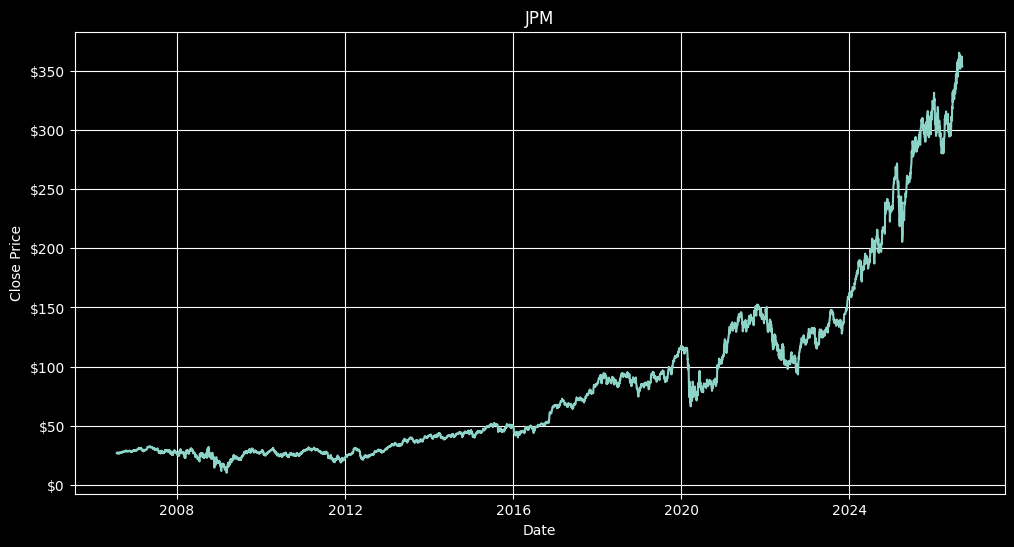

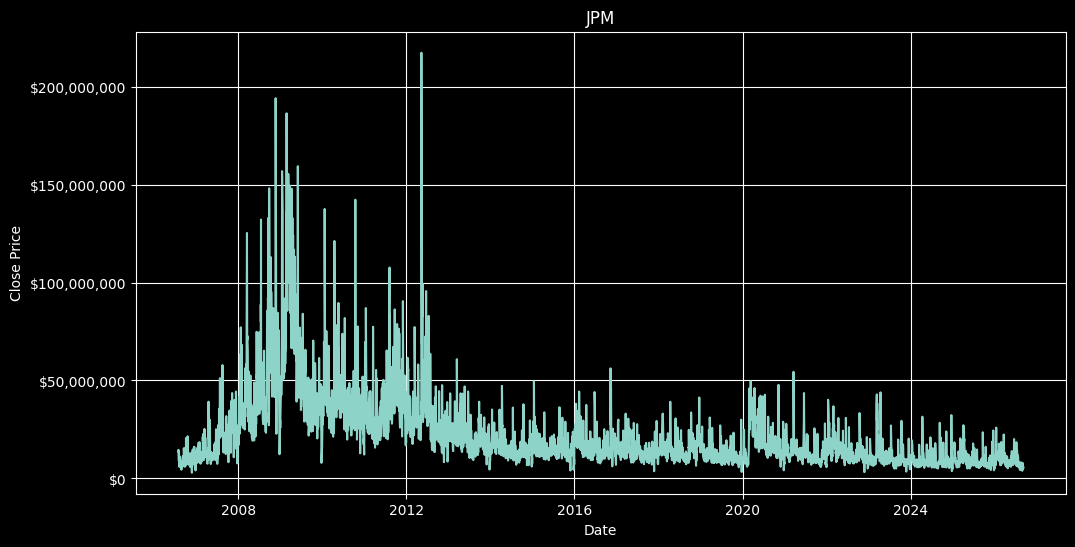

In [98]:
class Plot:
    def __init__(self, x, y):
        self.x = x
        self.y = y
    def line_plot(self, x, y):
        from matplotlib.ticker import FuncFormatter
        plt.style.use('dark_background')
        plt.figure(figsize=(12, 6))
        plt.plot(x, y)
        plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'${x:,.0f}'))
        plt.title("JPM")
        plt.xlabel("Date")
        plt.ylabel("Close Price")
        plt.grid()
        plt.show()
    def bar_plot(self, x, y):
        from matplotlib.ticker import FuncFormatter
        plt.style.use('dark_background')
        plt.figure(figsize=(12, 6))
        plt.bar(x, y)
        plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'${x:,.0f}'))
        plt.title("JPM")
        plt.xlabel("Date")
        plt.ylabel("Close Price")
        plt.grid()
        plt.show()

#Close price plot
my_plot = Plot(x, y).line_plot(x[6654:],y[6654:])

#Volume plot
my_plot = Plot(x,y).line_plot(x = jpm.index[6654:], y = jpm.Volume[6654:])

## Moving Averages

Moving averages smooth out day-to-day noise in a price series so that the underlying trend is easier to see. They are useful for determining trend direction and for identifying potential support and resistance levels. A 200-day moving average is commonly used as a long-term trend indicator, a 40-day (often 50-day) moving average is used for a medium-term trend, and a very short window like a 3-day moving average tracks near-term swings closely and reacts quickly to recent price moves. It is not, strictly speaking, an intraday indicator, since it is still built from daily closing prices rather than prices within a single trading day.

It is important to keep in mind that moving averages are just one of many technical indicators and should be used alongside other analysis tools and market research. Different securities and market regimes may call for different moving average windows, and there is no single "correct" length. Ultimately, the choice of window depends on the time horizon and strategy of the person using it.

In [99]:
class StockMovingAverageShort:
    def __init__(self, ticker):
        self.ticker = ticker    
    def moving_average(self, ticker):
        stock = yf.Ticker(ticker).history(period="max")
        stock['Price_shift_1'] = stock['Close'].shift(-1)
        stock['Price_difference'] = stock['Price_shift_1'] - stock['Close']
        stock['return'] = stock['Price_difference'] / stock['Close']
        stock['Direction'] = np.where(stock['return'] > 0, 1, -1)   
        stock['3_day MA'] = stock['Close'].rolling(window=3).mean()
        stock['40_day MA'] = stock['Close'].rolling(window=40).mean()
        stock['200_day MA'] = stock['Close'].rolling(window=200).mean()
        return stock

A note on the columns above: `Price_shift_1`, `Price_difference`, `return`, and `Direction` are all built using `shift(-1)`, which pulls tomorrow's close back onto today's row. That makes these columns look forward in time rather than backward. They are useful as labels for describing what actually happened the next trading day, but they should not be treated as features available at the time of a trading decision, since the real next-day price is obviously not known in advance. This is a common source of look-ahead bias in return-prediction notebooks.

The `3_day MA`, `40_day MA`, and `200_day MA` columns, by contrast, are genuine backward-looking rolling averages: each row only uses that day's close and the closes before it, computed with `Series.rolling(window=n).mean()`. The original version of this cell added the current close price on top of the rolling mean (`stock['Close'] + stock['Close'].rolling(window=n).mean()`), which is not what a moving average is and inflated every value. That has been corrected here so each `_day MA` column is just the plain rolling average of `Close`.

In [100]:
obj = StockMovingAverageShort("JPM").moving_average("JPM")
obj.columns

/opt/anaconda3/envs/quant-env/lib/python3.11/site-packages/yfinance/scrapers/history.py:204: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.utcnow()


Index(['Open', 'High', 'Low', 'Close', 'Volume', 'Dividends', 'Stock Splits',
       'Price_shift_1', 'Price_difference', 'return', 'Direction', '3_day MA',
       '40_day MA', '200_day MA'],
      dtype='str')

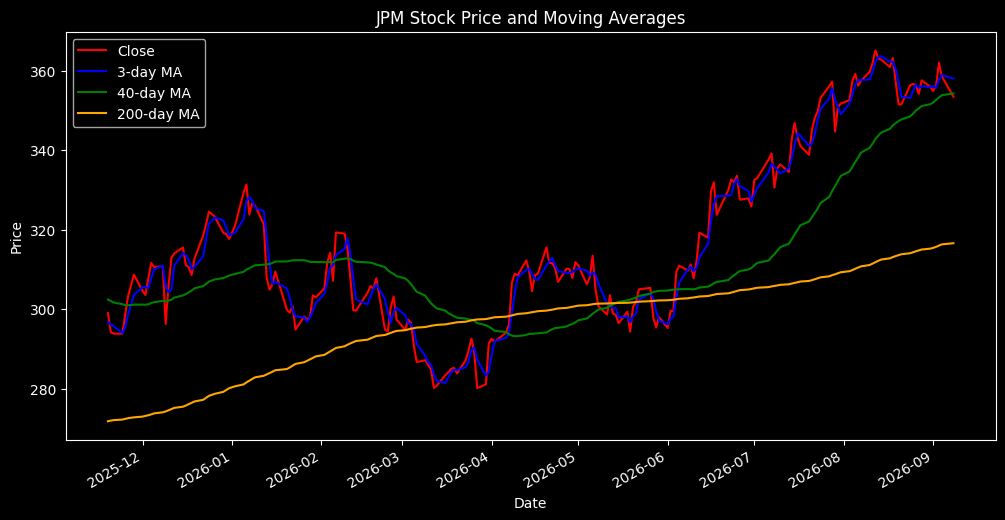

In [101]:
# Moving Average Plot
fig, ax = plt.subplots(figsize=(12, 6))
obj['Close'].tail(200).plot(label='Close', ax=ax, color="red")
obj['3_day MA'].tail(200).plot(label='3-day MA', ax=ax, color="blue")
obj['40_day MA'].tail(200).plot(label='40-day MA', ax=ax, color="green")
obj['200_day MA'].tail(200).plot(label='200-day MA', ax=ax, color="orange")
plt.title("JPM Stock Price and Moving Averages")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()

## Returns

This section plots the daily forward return computed in the `StockMovingAverageShort` class above. Since that return uses `shift(-1)`, each point represents the percentage move from that day's close to the next day's close, so the chart is best read as "how the stock actually moved the following day" rather than as a live trading signal.

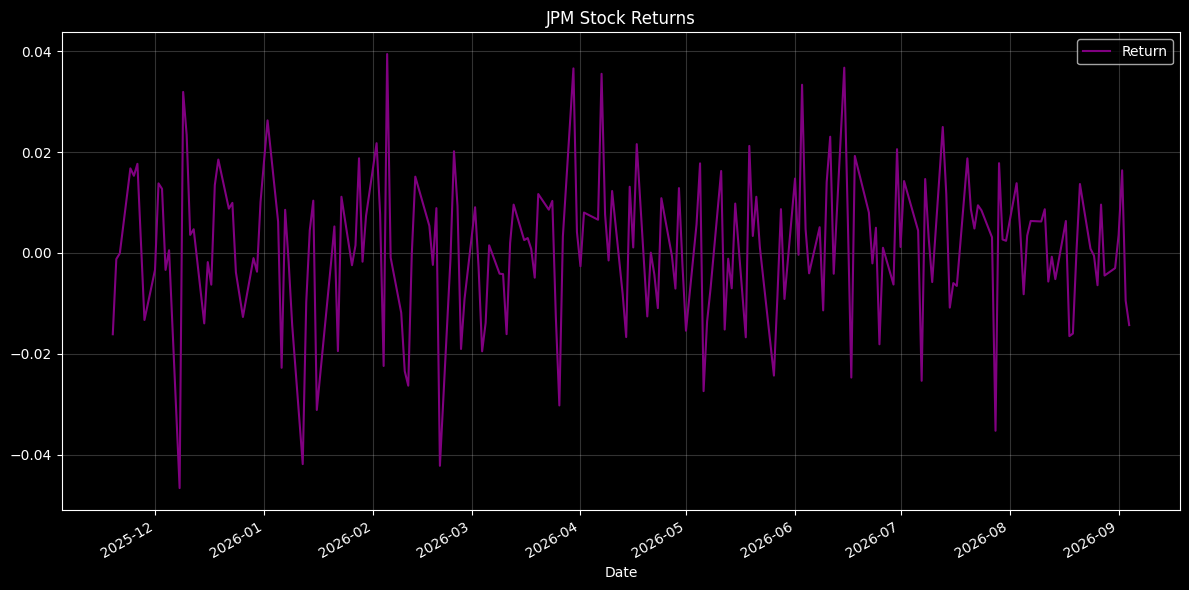

In [102]:
# Return plot
fig, ax = plt.subplots(figsize=(12, 6))
obj['return'].tail(200).plot(label='Return', ax=ax, color="purple")
ax.set_xlabel('Date')
ax.set_title('JPM Stock Returns')
ax.legend()
ax.grid(color='white', alpha=0.20)
plt.tight_layout()
plt.show()

## Getting 5 Years of Data Using an API Key

The `financetoolkit` package pulls fundamental financial statement data (income statement, balance sheet, cash flow statement, and related ratios) rather than just price history. Unlike `yfinance`, it requires a free or paid API key from financetoolkit.com. The key should never be hardcoded directly into a notebook since anyone who sees it can use it under your account and quota. The cell below reads the key from an environment variable (`FINANCETOOLKIT_API_KEY`) instead. Set it in your shell before launching Jupyter, for example with `export FINANCETOOLKIT_API_KEY=your_key_here`, or load it from a local `.env` file with a package like `python-dotenv`.

By default, `Toolkit.get_cash_flow_statement()` with `quarterly=False` returns annual data going back five years.

In [103]:
import os

ticker = "JPM"
api_key = os.environ.get("FINANCETOOLKIT_API_KEY")
if not api_key:
    raise ValueError(
        "Set the FINANCETOOLKIT_API_KEY environment variable before running this cell."
    )

companies = Toolkit(
    tickers=ticker,
    api_key=api_key,
    quarterly=False,   # False = annual 
)

cash_flow_statement_annually = companies.get_cash_flow_statement()
cash_flow_statement_annually.to_csv("cash_flow_statement_annually.csv")
cash_flow_statement_annually.columns

ValueError: Set the FINANCETOOLKIT_API_KEY environment variable before running this cell.

## Net Income

Net income is the company's total profit after all expenses, taxes, and interest are subtracted from revenue. It appears at the top of the cash flow statement (under the indirect method) as the starting point before non-cash adjustments and working capital changes are layered in to arrive at operating cash flow.

Net cash in a company's cash flow statement refers to the amount of cash that is generated or used by a company in a specific period of time, such as a quarter or a year. It is calculated by subtracting all of the cash outflows from the cash inflows that the company has experienced during that time period.

The net cash figure is important because it shows the company's ability to generate cash, which is a crucial metric for investors and lenders. A positive net cash flow indicates that a company is generating more cash than it is using, which is generally seen as a good sign. A negative net cash flow, on the other hand, means that the company is using more cash than it is generating, which could be a cause for concern, though it is not automatically alarming; a growing company can post negative overall cash flow in a given year if it is investing heavily, as long as it has the financing or reserves to support that spending.

The cash flow statement breaks net cash into three subcategories, each covered in its own section below. Net cash from operating activities is the cash generated from the company's core, day-to-day business, such as taking in deposits, making loans, and collecting fees, in JPM's case. Net cash from investing activities is the cash used or generated from the company's investments, such as buying or selling securities, property, plant, and equipment. Net cash from financing activities is the cash generated or used from financing activities, such as issuing or repaying debt, issuing new stock, or paying dividends. Reading all three together, rather than any single one in isolation, gives a fuller picture of where a company's cash is coming from and where it is going.

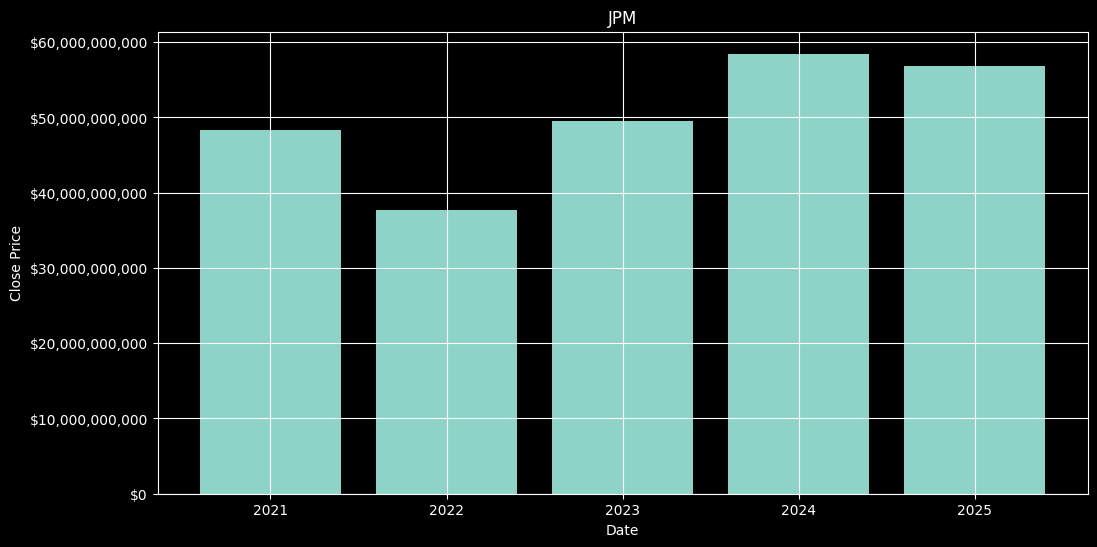

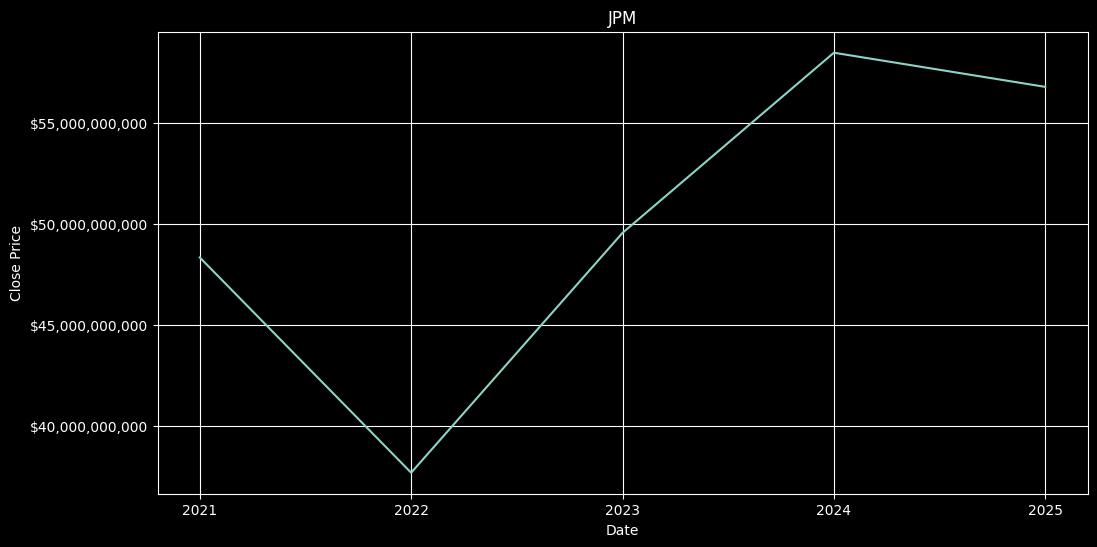

Net Income DataFrame:
   Date    Net Income
0  2021 48334000000.0
1  2022 37676000000.0
2  2023 49552000000.0
3  2024 58471000000.0
4  2025 56780000000.0


In [ ]:
class CashFlow:
    def __init__(self, data):
        self.data = data

    def DataSeparator(self, data):
        x = data.index
        y = data.values
        return x, y

x_dates, y_values = CashFlow(cash_flow_statement_annually).DataSeparator(
    cash_flow_statement_annually.loc['Net Income']
)

net_income_df = pd.DataFrame({
    'Date': x_dates.astype(str),   # Period objects -> plain strings like '2021'
    'Net Income': y_values
})
net_income_df = net_income_df.sort_values(by='Date')

x = net_income_df['Date'].values
y = net_income_df['Net Income'].values

my_bar_plot = Plot(x, y).bar_plot(x, y)
my_line_plot = Plot(x, y).line_plot(x, y)
print("Net Income DataFrame:")
print(net_income_df)

## Change in Working Capital

Working capital is the difference between a company's current assets and current liabilities. It represents the funds available to a company to fund its day-to-day operations, such as covering payroll, inventory, and short-term obligations without having to raise outside financing. The "change in working capital" line on a cash flow statement measures how that pool of short-term resources changed from one period to the next, and it gets folded into cash flow from operations because tying up more cash in short-term assets (or paying down short-term liabilities faster) reduces the cash actually available to the business, even if reported profit looks healthy.

The trend of working capital over the years has been fluctuating in this data, with some years showing a positive change and others a negative change. A positive change in working capital typically means cash was tied up (used) growing current assets faster than current liabilities, while a negative change often means cash was freed up, for example by collecting receivables faster or stretching out payables. Neither direction is inherently good or bad on its own. What matters is whether the swings are deliberate and manageable or a sign of deteriorating liquidity and difficulty funding operations.

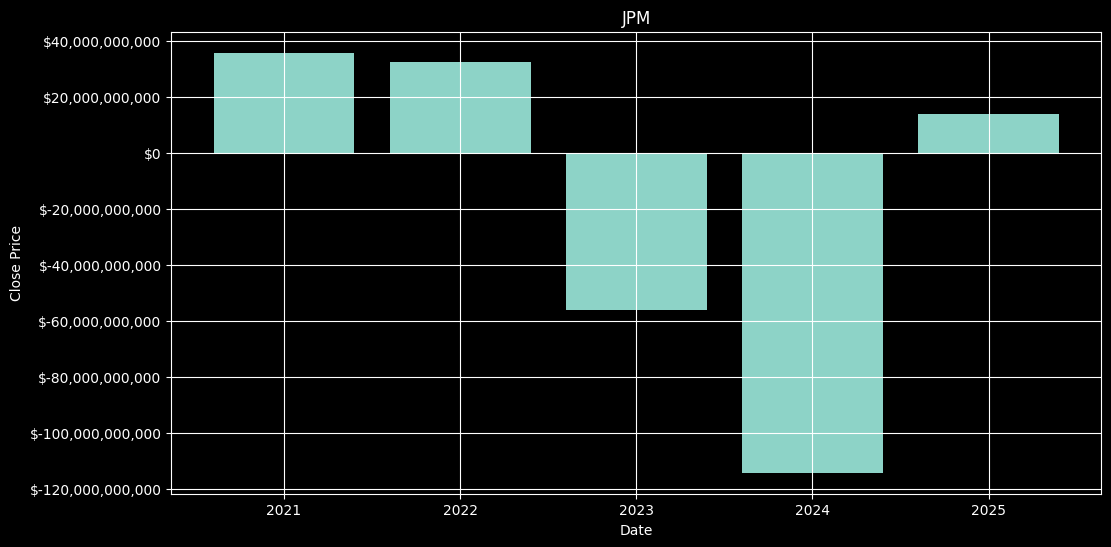

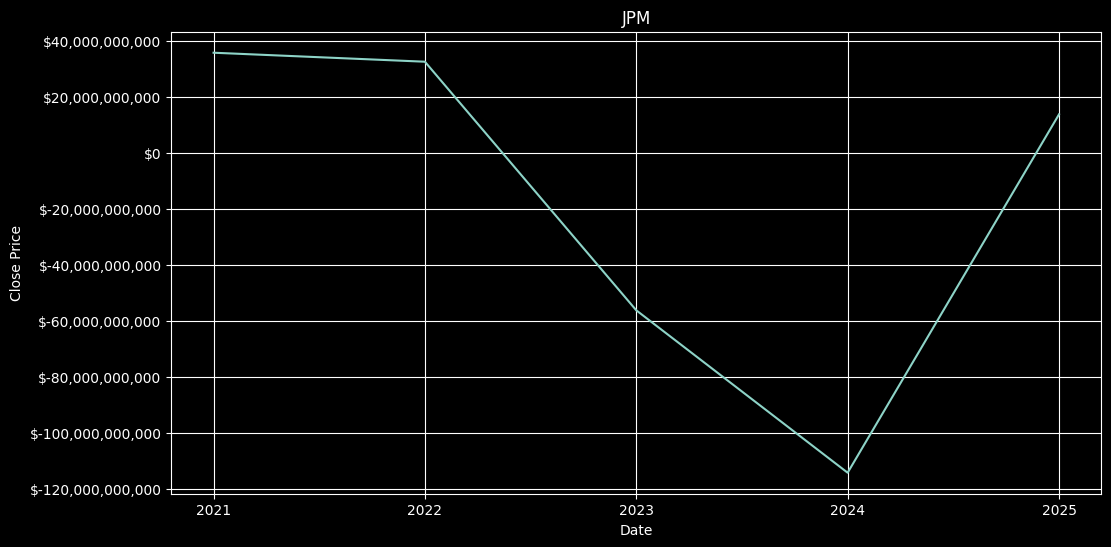

Change in Working Capital DataFrame:
   Date  Change in Working Capital
0  2021              35901000000.0
1  2022              32686000000.0
2  2023             -56168000000.0
3  2024            -114220000000.0
4  2025              13866000000.0


In [ ]:
x2_dates, y2_values = CashFlow(cash_flow_statement_annually).DataSeparator(
    cash_flow_statement_annually.loc['Change in Working Capital']
)
change_wc_df = pd.DataFrame({'Date': x2_dates.astype(str), 'Change in Working Capital': y2_values})
change_wc_df = change_wc_df.sort_values(by='Date')
x2 = change_wc_df['Date'].values
y2 = change_wc_df['Change in Working Capital'].values
my_bar_plot2 = Plot(x2, y2).bar_plot(x2, y2)
my_line_plot2 = Plot(x2, y2).line_plot(x2, y2)
print("Change in Working Capital DataFrame:")
print(change_wc_df)

## Net Cash Provided by Operating Activities

Net cash provided by operating activities, often shortened to operating cash flow, measures the cash a company generates from its normal business operations. It is a line item on a company's cash flow statement, and it reflects the cash inflows and outflows that result from operating activities, such as net income adjusted for non-cash items like depreciation and the changes in working capital covered in the previous section. Positive net cash provided by operating activities indicates that a company is generating more cash than it is using in its operations, while negative net cash provided by operating activities indicates that a company is using more cash than it is generating from operations.

Operating cash flow is generally considered a cleaner signal of a company's health than net income, because net income can be shaped by non-cash accounting choices such as depreciation schedules, while operating cash flow reflects cash that actually moved. A company can be profitable on paper and still run into trouble if its operating cash flow does not follow.

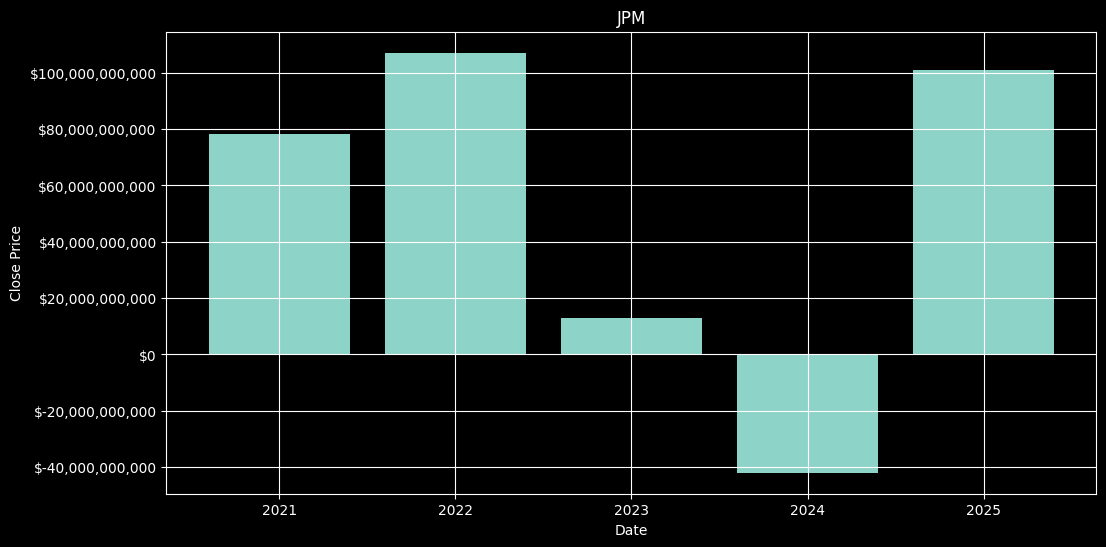

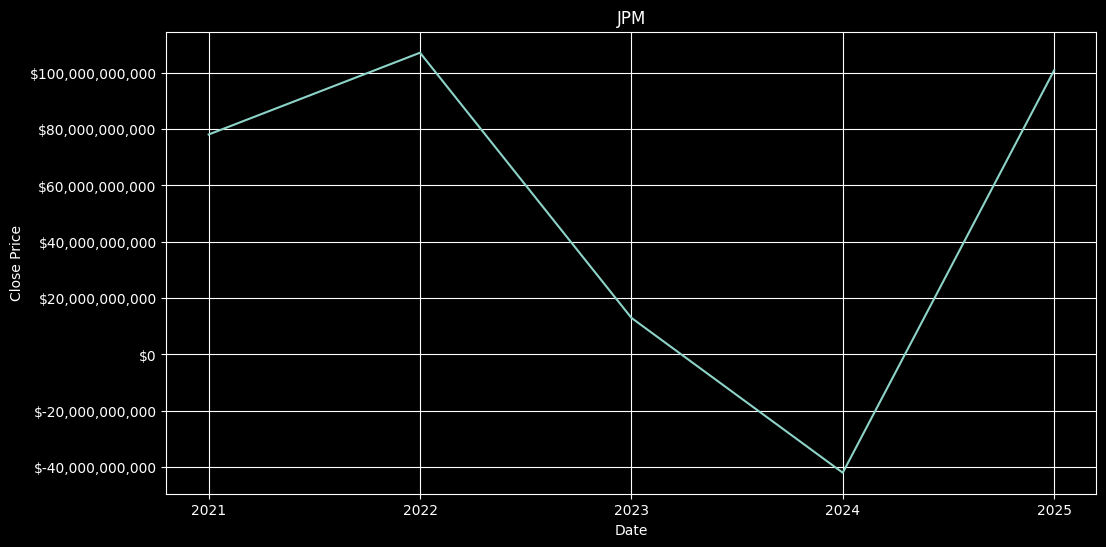

Cash Flow from Operations DataFrame:
   Date  Cash Flow from Operations
0  2021              78084000000.0
1  2022             107119000000.0
2  2023              12974000000.0
3  2024             -42012000000.0
4  2025             100867000000.0


In [ ]:
x3_dates, y3_values = CashFlow(cash_flow_statement_annually).DataSeparator(
    cash_flow_statement_annually.loc['Cash Flow from Operations']
)
cfo_df = pd.DataFrame({'Date': x3_dates.astype(str), 'Cash Flow from Operations': y3_values})
cfo_df = cfo_df.sort_values(by='Date')
x3 = cfo_df['Date'].values
y3 = cfo_df['Cash Flow from Operations'].values
my_bar_plot3 = Plot(x3, y3).bar_plot(x3, y3)
my_line_plot3 = Plot(x3, y3).line_plot(x3, y3)
print("Cash Flow from Operations DataFrame:")
print(cfo_df)

## Net Cash for Investing Activities

Net cash used for investing activities is a metric used to measure the amount of cash used by a company for investing activities such as buying property, plant, and equipment, purchasing or selling securities, or acquiring other companies. This metric is typically found in a company's cash flow statement and is used to understand how much of a company's cash is going toward growing or maintaining its asset base versus being generated for other uses.

For most healthy, growing companies, cash flow from investing is negative in most years, since ongoing investment in the business (capital expenditures, acquisitions) is a normal and expected use of cash. A large positive figure is not necessarily a sign of strength; it can simply mean the company sold off assets or investments during that period, which is worth investigating rather than assuming is good news.

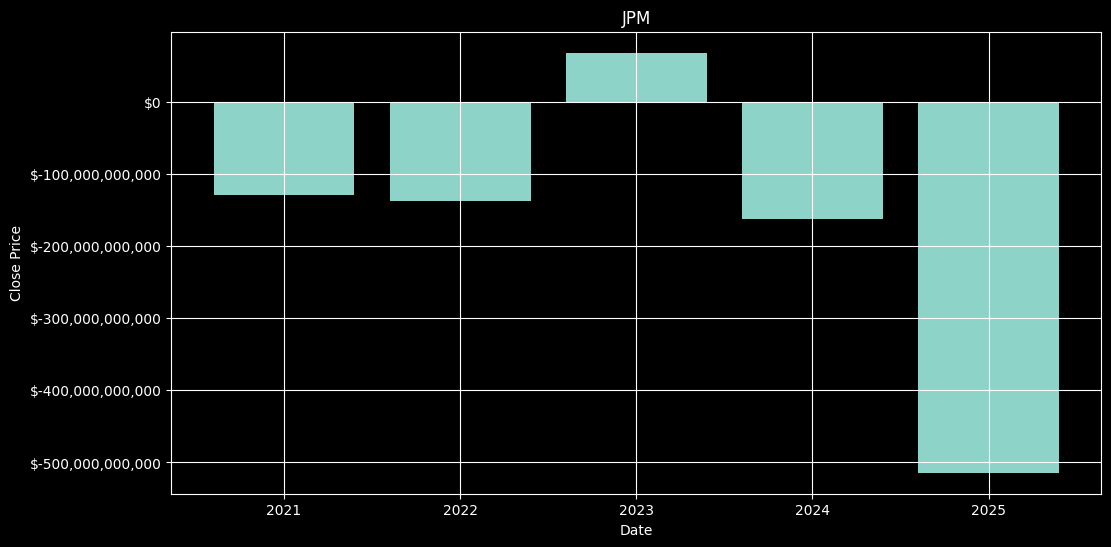

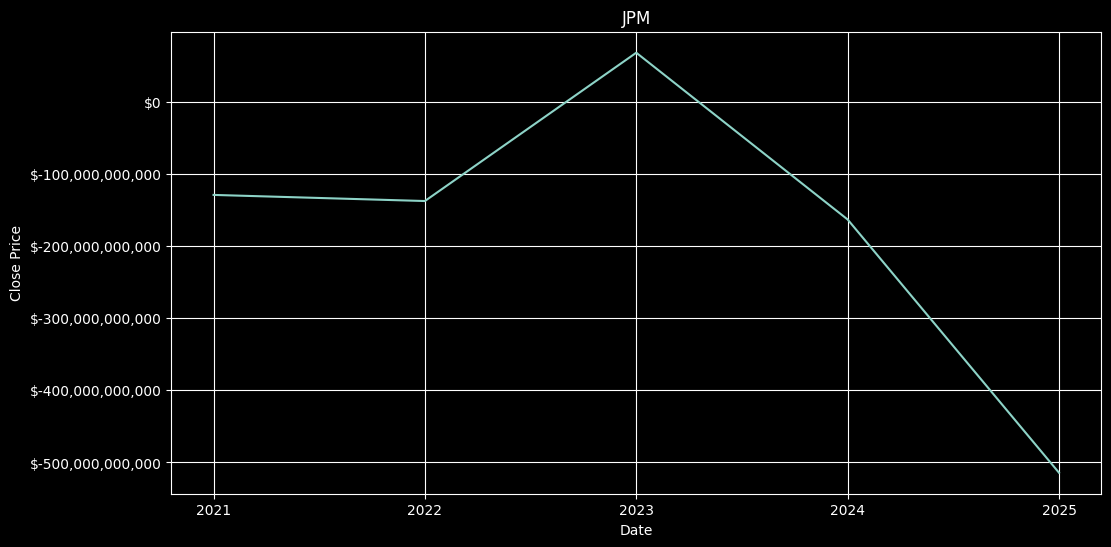

Cash Flow from Investing DataFrame:
   Date  Cash Flow from Investing
0  2021           -129344000000.0
1  2022           -137819000000.0
2  2023             67643000000.0
3  2024           -163403000000.0
4  2025           -514214000000.0


In [ ]:
x4_dates, y4_values = CashFlow(cash_flow_statement_annually).DataSeparator(
    cash_flow_statement_annually.loc['Cash Flow from Investing']
)
cfi_df = pd.DataFrame({'Date': x4_dates.astype(str), 'Cash Flow from Investing': y4_values})
cfi_df = cfi_df.sort_values(by='Date')
x4 = cfi_df['Date'].values
y4 = cfi_df['Cash Flow from Investing'].values
my_bar_plot4 = Plot(x4, y4).bar_plot(x4, y4)
my_line_plot4 = Plot(x4, y4).line_plot(x4, y4)
print("Cash Flow from Investing DataFrame:")
print(cfi_df)

## Code to Speed Up the Process

Rather than repeating the same "separate the dates and values, build a DataFrame, sort it, and plot it" pattern for every remaining line item, this cell wraps that logic into a single `pull_and_plot` function. Each section below calls this function with a different row label from `cash_flow_statement_annually`, which keeps the rest of the notebook concise.

In [ ]:
def pull_and_plot(statement, row_label, n=None):
    x_dates, y_values = CashFlow(statement).DataSeparator(statement.loc[row_label])
    df = pd.DataFrame({'Date': x_dates.astype(str), row_label: y_values}).sort_values(by='Date')
    x, y = df['Date'].values, df[row_label].values
    Plot(x, y).bar_plot(x, y)
    Plot(x, y).line_plot(x, y)
    return x, y


## Net Debt Issued

Net Debt Issued represents the net cash flow generated or used from a company's debt-related financing activities during a given period. It is calculated as total new debt borrowed minus total debt repaid over that period, combining both long-term and short-term borrowing into a single figure rather than reporting issuance and repayment separately. A positive value means the company issued more debt than it repaid, so its overall debt load grew during the period, often to fund expansion, acquisitions, or share buybacks. A negative value means the company repaid more debt than it issued, signaling deleveraging and a reduction in its overall debt burden. Because it is a net figure, it captures the direction of a company's borrowing activity over time rather than the separate gross amounts of new debt raised and debt paid down.

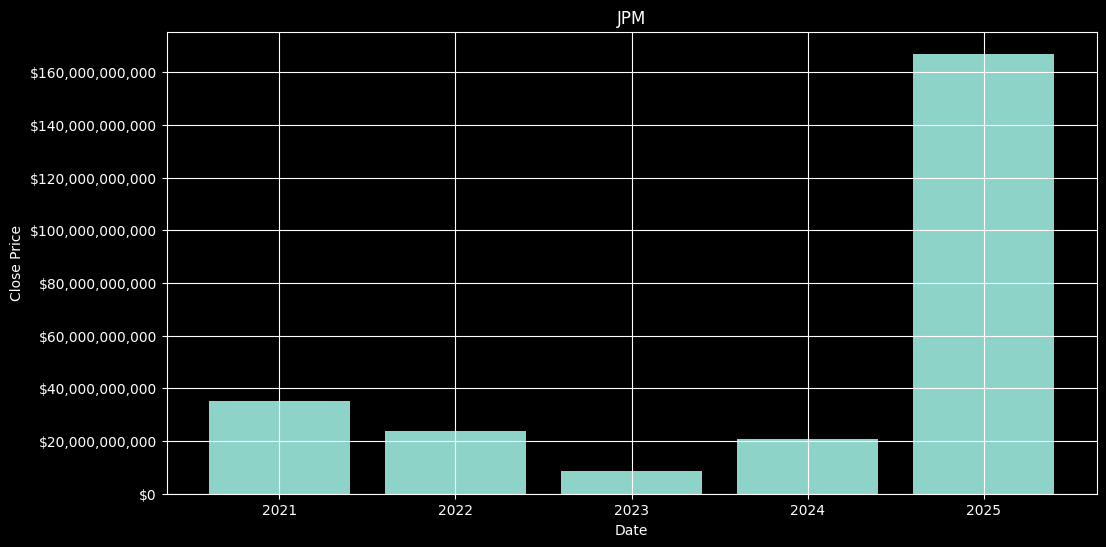

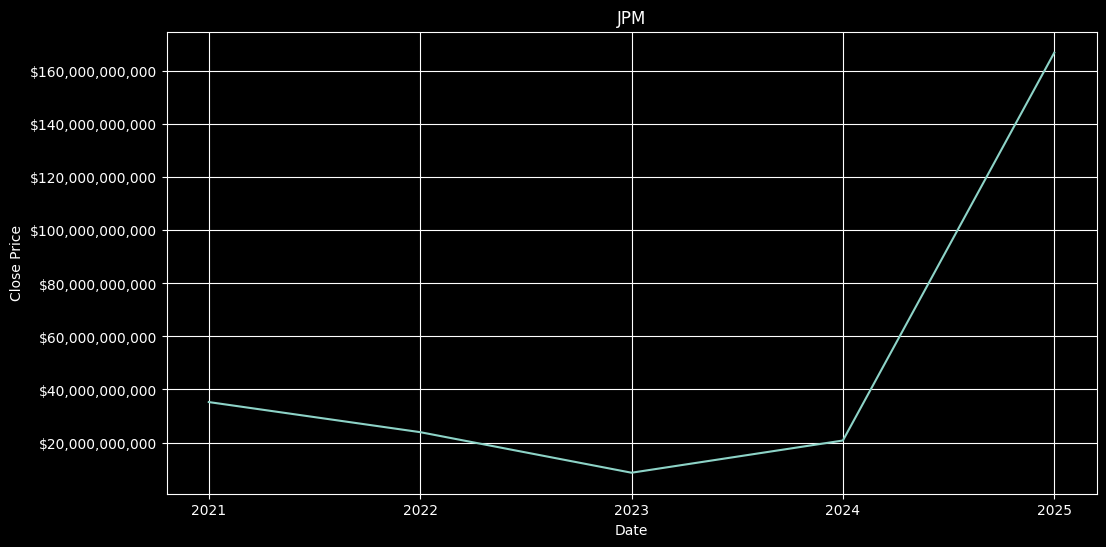

Net Debt Issued DataFrame:
   Date  Net Debt Issued
0  2021    35250000000.0
1  2022    23902000000.0
2  2023     8603000000.0
3  2024    20749000000.0
4  2025   166996000000.0


In [ ]:
x5, y5 = pull_and_plot(cash_flow_statement_annually, 'Net Debt Issued')
print("Net Debt Issued DataFrame:")
print(pd.DataFrame({'Date': x5.astype(str), 'Net Debt Issued': y5}).sort_values(by='Date'))

## Common Stock Issued

Common stock issued refers to the amount of new shares that a company has issued and sold to investors. This can include the issuance of new shares through an initial public offering (IPO) or subsequent offerings, such as secondary offerings, as well as shares issued for employee compensation plans. The proceeds from the sale of common stock can be used by the company to finance operations, pay off debt, or invest in growth initiatives. The amount of common stock issued can have a significant impact on a company's capital structure and its ability to raise capital in the future.

For a large, mature bank like JPM, common stock issuance tends to be modest relative to its size, since most large banks prefer to fund growth through retained earnings and debt rather than diluting existing shareholders. A spike in this figure is worth investigating alongside the company's stated reasons, such as regulatory capital requirements or a specific acquisition.

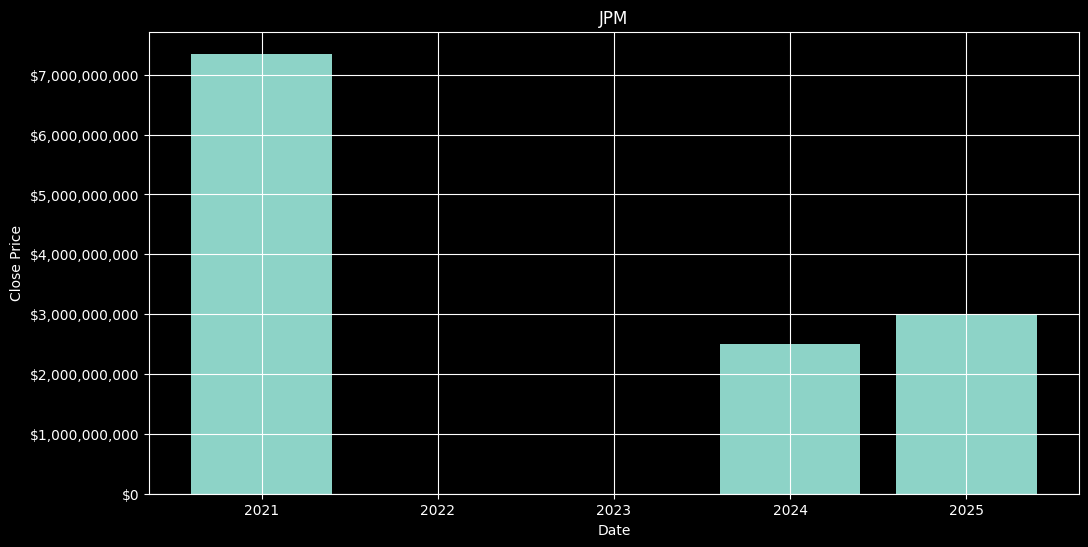

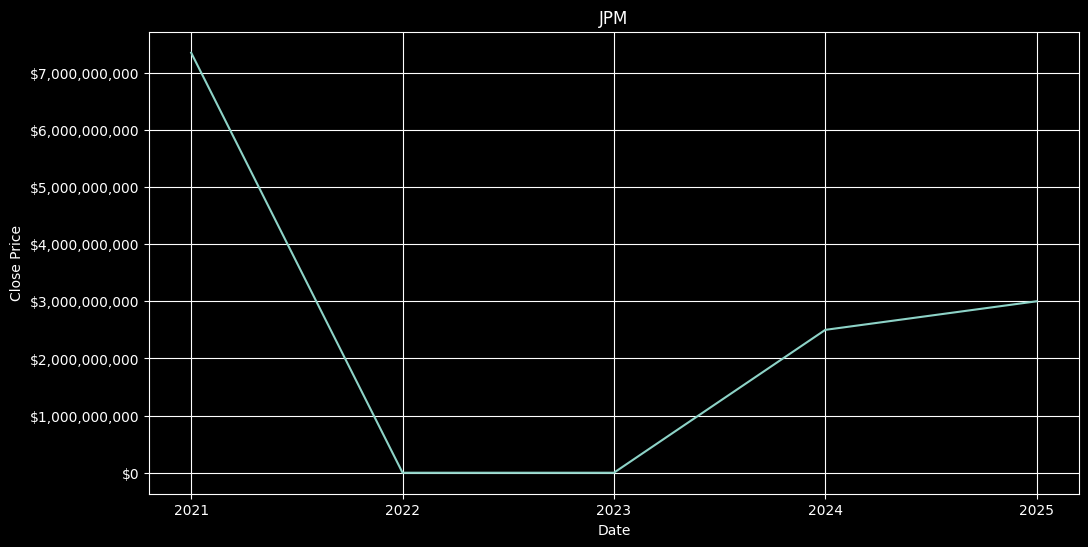

Common Stock Issued DataFrame:
   Date  Common Stock Issued
0  2021         7350000000.0
1  2022                  0.0
2  2023                  0.0
3  2024         2500000000.0
4  2025         3000000000.0


In [ ]:
x6, y6 = pull_and_plot(cash_flow_statement_annually, 'Common Stock Issued')
print("Common Stock Issued DataFrame:")
print(pd.DataFrame({'Date': x6.astype(str), 'Common Stock Issued': y6}).sort_values(by='Date'))

## Common Stock Purchased

Common stock purchased refers to the action taken by a company to buy back its own outstanding shares of common stock from the market or from shareholders, commonly called a share buyback or repurchase. This reduces the number of outstanding shares, thereby increasing the ownership stake of each remaining shareholder and also increasing earnings per share, since the same total earnings are now divided across fewer shares. Repurchasing common stock can be a signal to the market that a company believes its stock is undervalued, or it can simply be a way to return capital to shareholders as an alternative to paying dividends.

This line item is reported as a negative number on the cash flow statement, since it represents cash leaving the company to buy shares. Comparing the size of buybacks to dividends paid gives a sense of how a company prefers to return capital to shareholders.

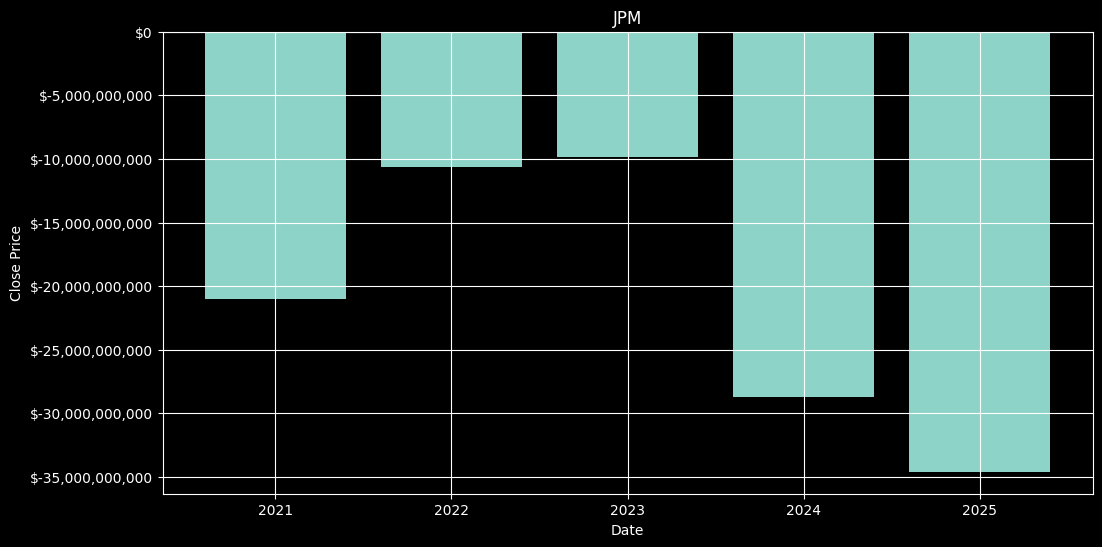

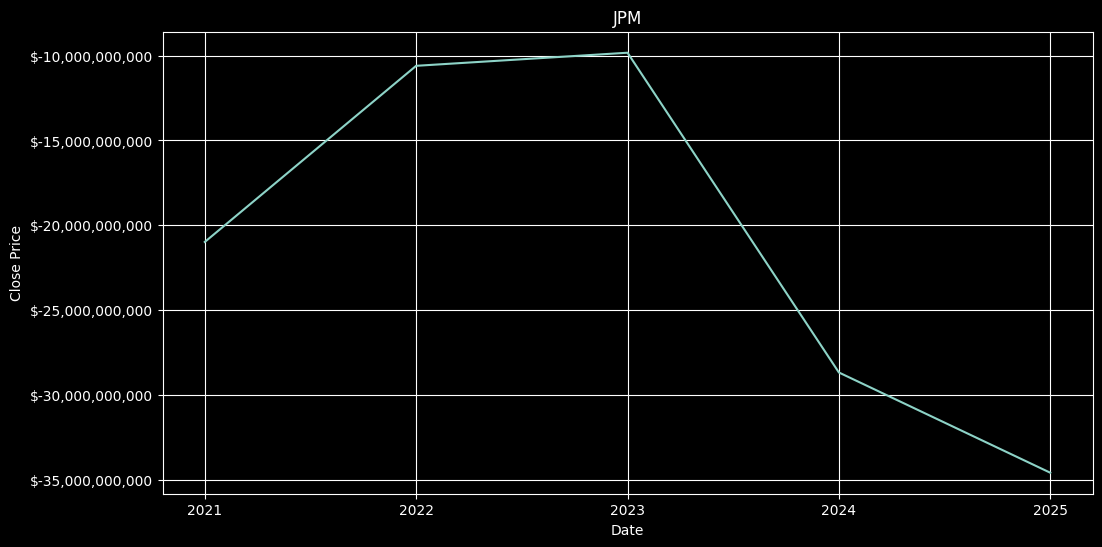

Common Stock Purchased DataFrame:
   Date  Common Stock Purchased
0  2021          -20983000000.0
1  2022          -10596000000.0
2  2023           -9824000000.0
3  2024          -28680000000.0
4  2025          -34591000000.0


In [ ]:
x7, y7 = pull_and_plot(cash_flow_statement_annually, 'Common Stock Purchased')
print("Common Stock Purchased DataFrame:")
print(pd.DataFrame({'Date': x7.astype(str), 'Common Stock Purchased': y7}).sort_values(by='Date'))

## Dividends Paid

Dividends paid is the cash a company distributes directly to shareholders, typically on a quarterly basis, as a portion of its profits. It appears as a cash outflow under financing activities. The dividends paid data provides insight into the company's ability to generate profits and its willingness to distribute a portion of those profits to its shareholders rather than reinvesting all of it back into the business or holding it in reserve.

A steadily growing dividend is often viewed favorably by investors as a sign of consistent profitability and management's confidence in future cash flows, since cutting a dividend once it has been established is generally seen as a strongly negative signal about the company's outlook.

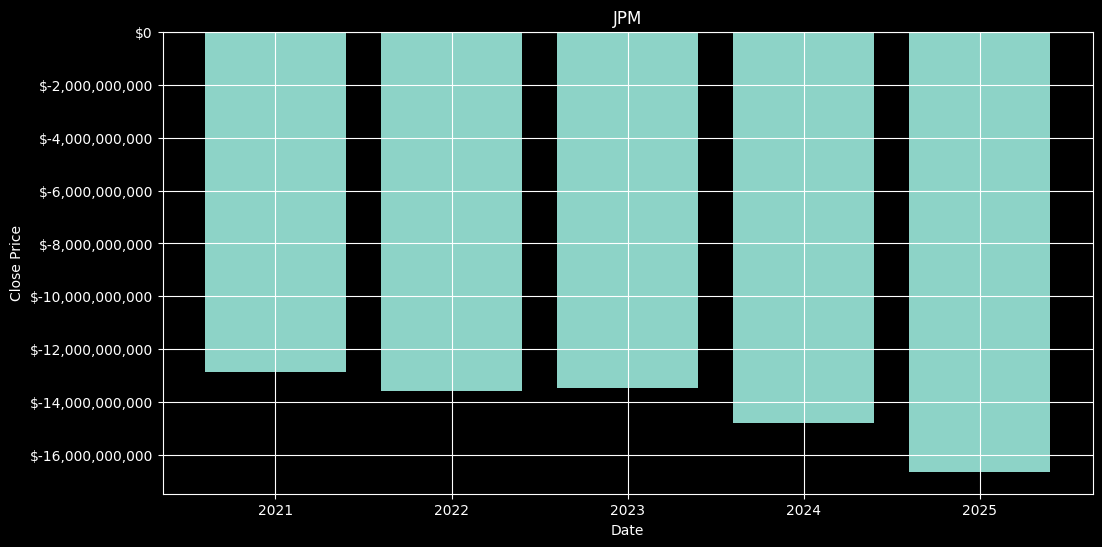

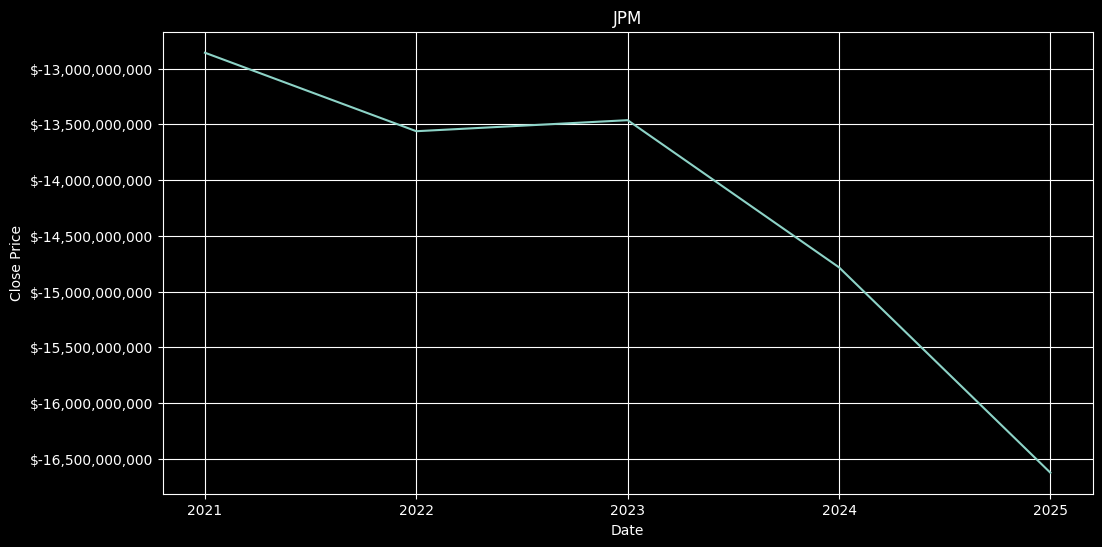

Dividends Paid DataFrame:
   Date  Dividends Paid
0  2021  -12858000000.0
1  2022  -13562000000.0
2  2023  -13463000000.0
3  2024  -14783000000.0
4  2025  -16625000000.0


In [ ]:
x8, y8 = pull_and_plot(cash_flow_statement_annually, 'Dividends Paid')
print("Dividends Paid DataFrame:")
print(pd.DataFrame({'Date': x8.astype(str), 'Dividends Paid': y8}).sort_values(by='Date'))

## Cash Flow from Financing

Net cash used or provided by financing activities refers to the cash inflows and outflows generated from a company's financing activities. These activities include issuing or repaying debt, issuing new shares of stock (equity), repurchasing shares of stock, and paying dividends to shareholders, all of which were covered individually in the sections above. The net cash used or provided by financing activities is calculated by subtracting the cash outflows from financing activities (such as debt repayment, share repurchases, or dividend payments) from the cash inflows (such as issuing debt or issuing new shares). This figure is important because it provides insight into how a company is financing its operations and growth, and whether it is a net borrower or a net repayer of capital during the period.

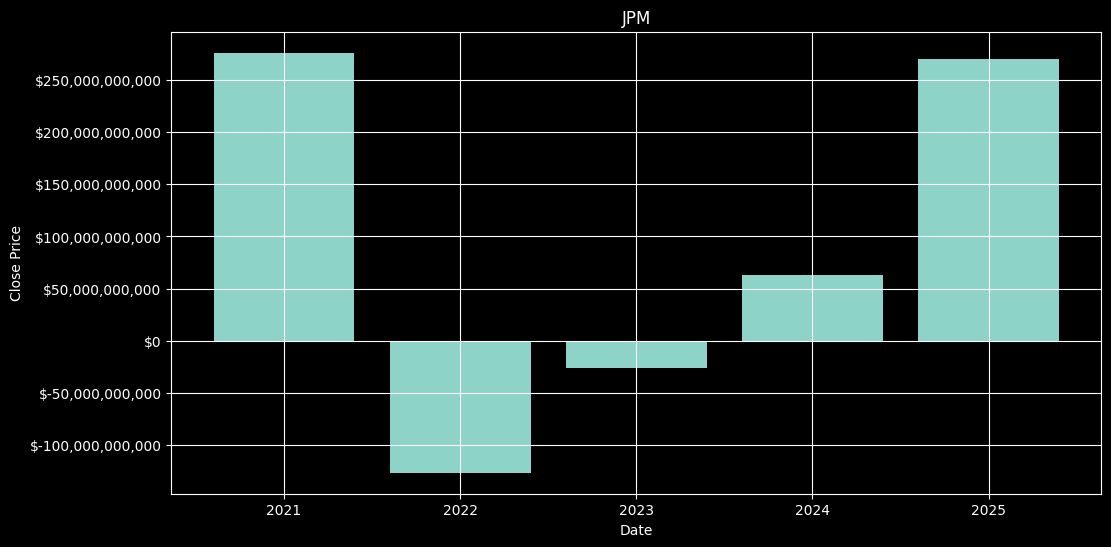

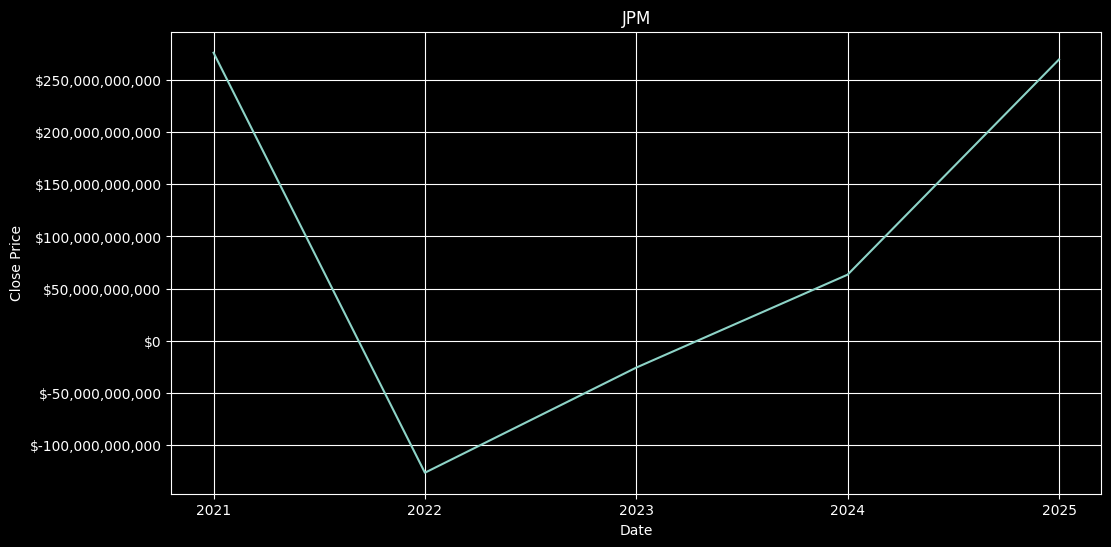

Cash Flow from Financing DataFrame:
   Date  Cash Flow from Financing
0  2021            275993000000.0
1  2022           -126257000000.0
2  2023            -25571000000.0
3  2024             63447000000.0
4  2025            269533000000.0


In [ ]:
x9, y9 = pull_and_plot(cash_flow_statement_annually, 'Cash Flow from Financing')
print("Cash Flow from Financing DataFrame:")
print(pd.DataFrame({'Date': x9.astype(str), 'Cash Flow from Financing': y9}).sort_values(by='Date'))

## Foreign Exchanges on Cash

The effect of foreign exchange changes on cash refers to the impact that changes in foreign currency exchange rates have on a company's cash balance. If a company holds cash balances in multiple currencies, changes in the exchange rates between those currencies and the company's reporting currency (US dollars, for JPM) can change the reported value of its cash even if the amount of foreign currency held has not changed at all. For example, if a company holds cash in euros and the euro weakens relative to the dollar, the dollar value of that cash balance falls even though the number of euros held stays the same. The "effect of foreign exchange changes on cash" line item in a cash flow statement isolates this currency translation effect from actual cash generated or spent.

For a large, globally active bank like JPM, this line item is typically small relative to the other cash flow categories, since it reflects a translation effect rather than an operating, investing, or financing decision.

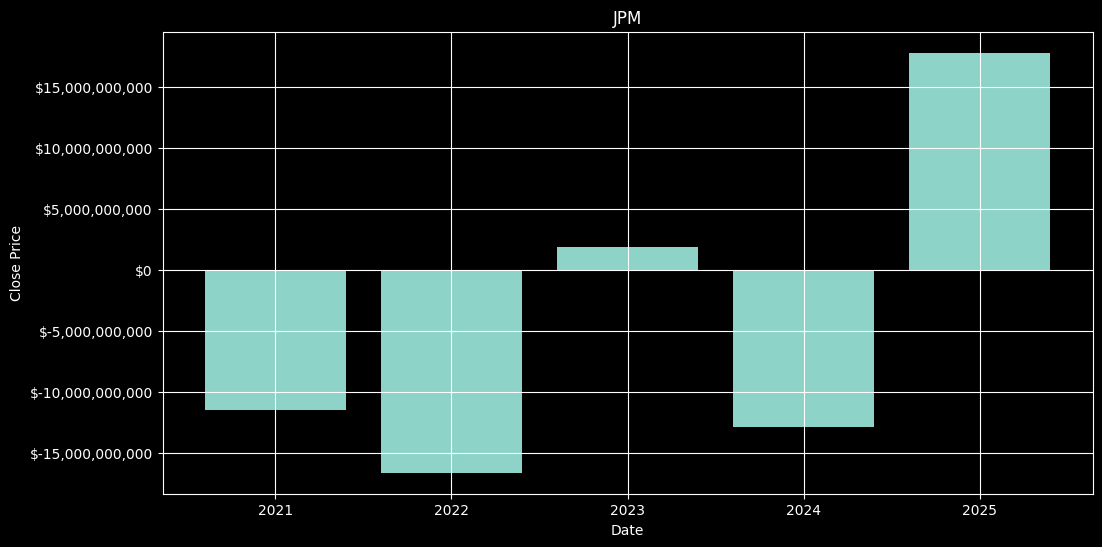

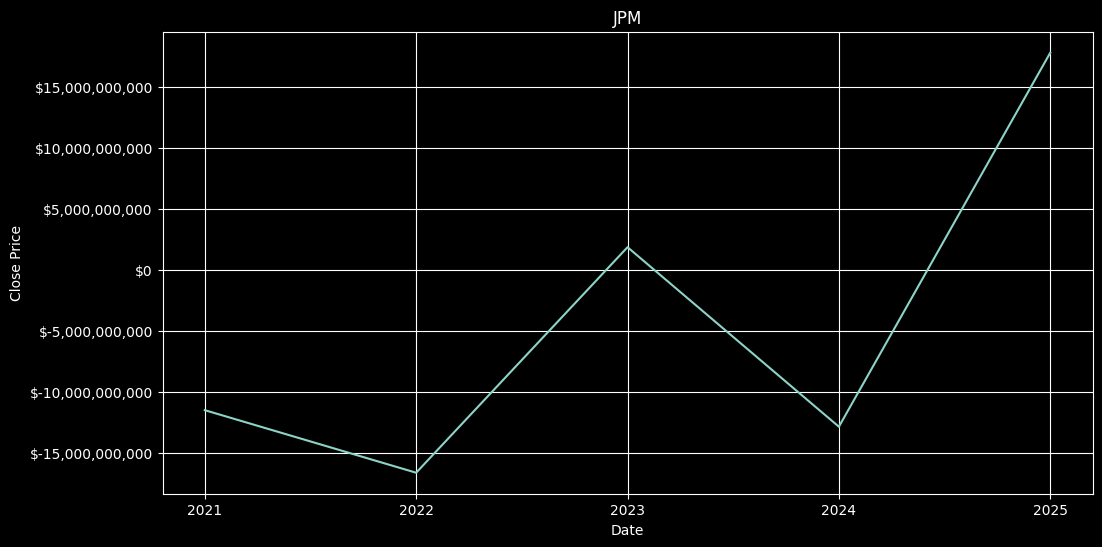

Forex Changes on Cash DataFrame:
   Date  Forex Changes on Cash
0  2021         -11508000000.0
1  2022         -16643000000.0
2  2023           1871000000.0
3  2024         -12866000000.0
4  2025          17835000000.0


In [ ]:
x10, y10 = pull_and_plot(cash_flow_statement_annually, 'Forex Changes on Cash')
print("Forex Changes on Cash DataFrame:")
print(pd.DataFrame({'Date': x10.astype(str), 'Forex Changes on Cash': y10}).sort_values(by='Date'))

## Net Change in Cash

The net change in cash refers to the overall increase or decrease in a company's cash balance over a given period of time. It is calculated as the sum of cash flow from operating activities, cash flow from investing activities, cash flow from financing activities, and the effect of foreign exchange changes on cash, which together account for every cash inflow and outflow during the period. In other words, it is the bottom line of the entire cash flow statement: the difference between cash at the beginning of the period and cash at the end of the period. The net change in cash can be a useful indicator of a company's financial stability and its ability to generate cash, though it should be read alongside its components, since a positive net change built on financing inflows tells a very different story than one built on operating cash flow.

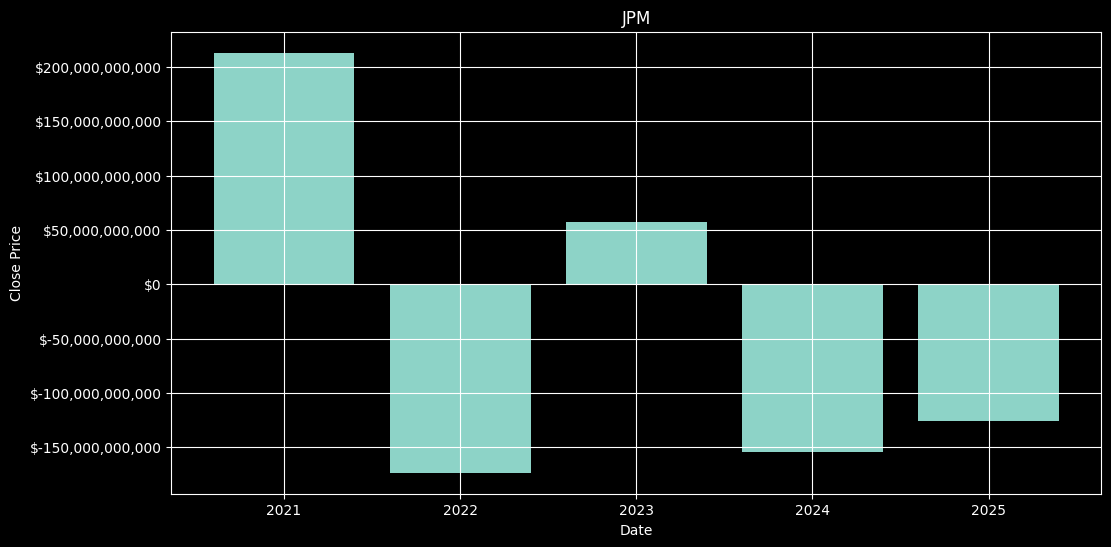

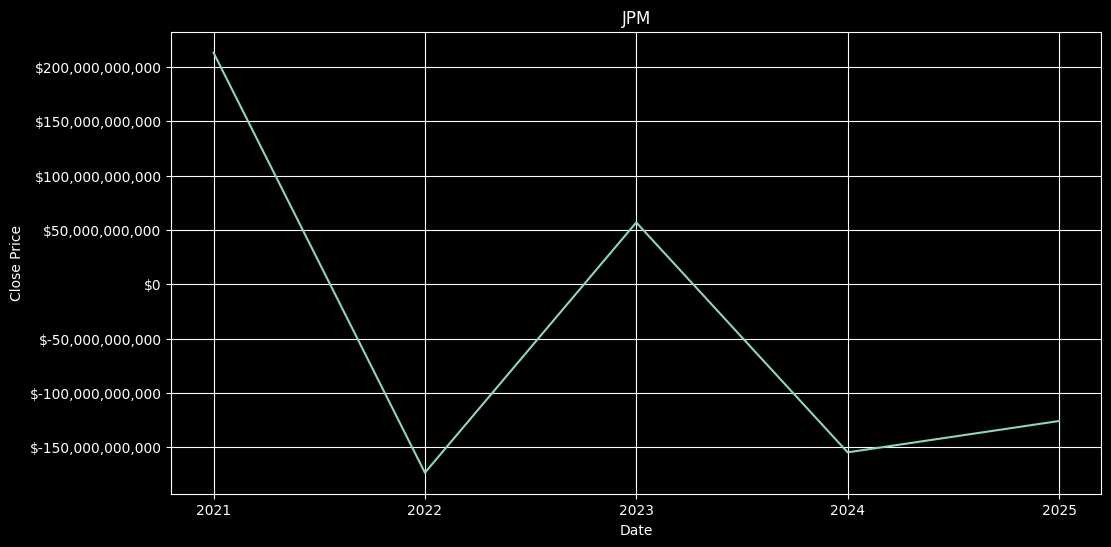

Net Change in Cash DataFrame:
   Date  Net Change in Cash
0  2021      213225000000.0
1  2022     -173600000000.0
2  2023       56917000000.0
3  2024     -154834000000.0
4  2025     -125979000000.0


In [ ]:
x11, y11 = pull_and_plot(cash_flow_statement_annually, 'Net Change in Cash')
print("Net Change in Cash DataFrame:")
print(pd.DataFrame({'Date': x11.astype(str), 'Net Change in Cash': y11}).sort_values(by='Date'))

## Cash at End of Period

Cash at end of period is the amount of cash a company has on hand at the close of a specific reporting period, typically the end of a quarter or a year. It is the final line of the cash flow statement, equal to cash at the beginning of the period plus the net change in cash covered in the previous section. This figure is an important measure of liquidity, since it reflects the cash a company actually has available to meet near-term obligations, separate from any assets that are harder to convert to cash quickly.

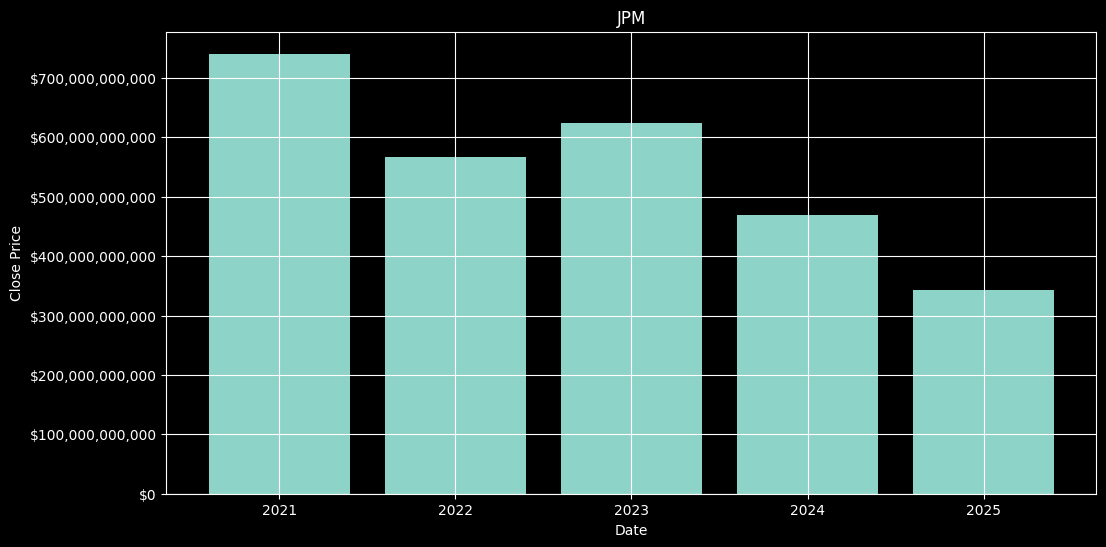

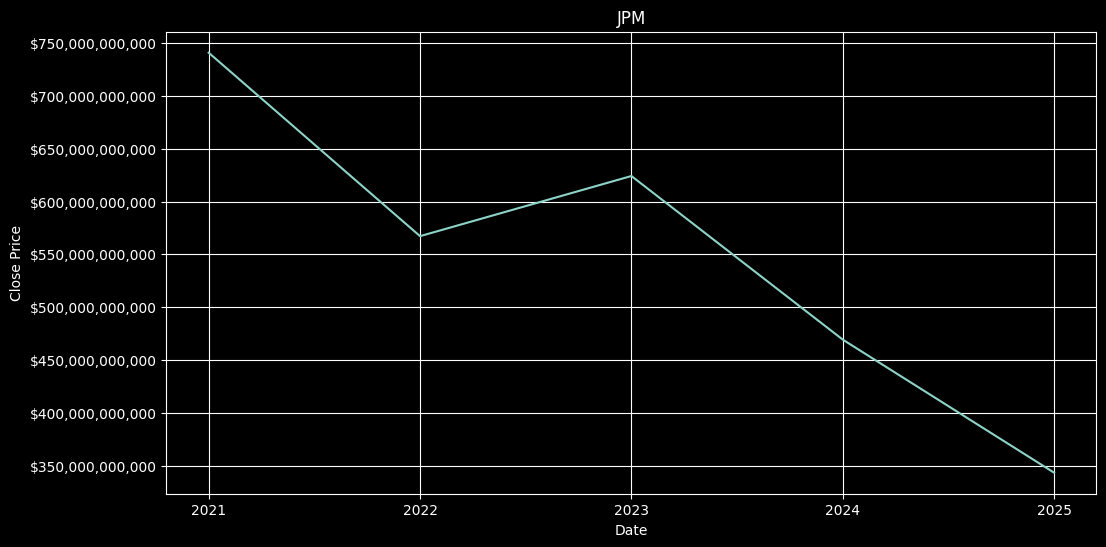

Cash End of Period DataFrame:
   Date  Cash End of Period
0  2021      740834000000.0
1  2022      567234000000.0
2  2023      624151000000.0
3  2024      469317000000.0
4  2025      343338000000.0


In [ ]:
x12, y12 = pull_and_plot(cash_flow_statement_annually, 'Cash End of Period')
print("Cash End of Period DataFrame:")
print(pd.DataFrame({'Date': x12.astype(str), 'Cash End of Period': y12}).sort_values(by='Date'))

## Cash at Beginning of Period

Cash at beginning of period refers to the amount of cash a company has on hand at the start of a specific financial period, such as a fiscal quarter or year. It is simply the prior period's "cash at end of period" carried forward, which is why plotting this series alongside cash at end of period is a useful way to sanity-check that the cash flow statement ties together correctly from one year to the next.

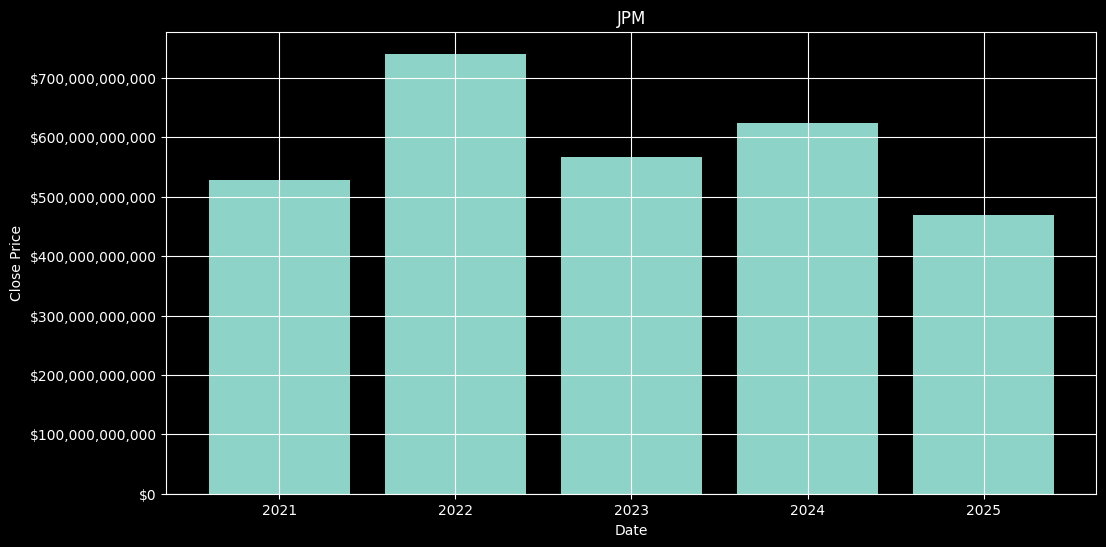

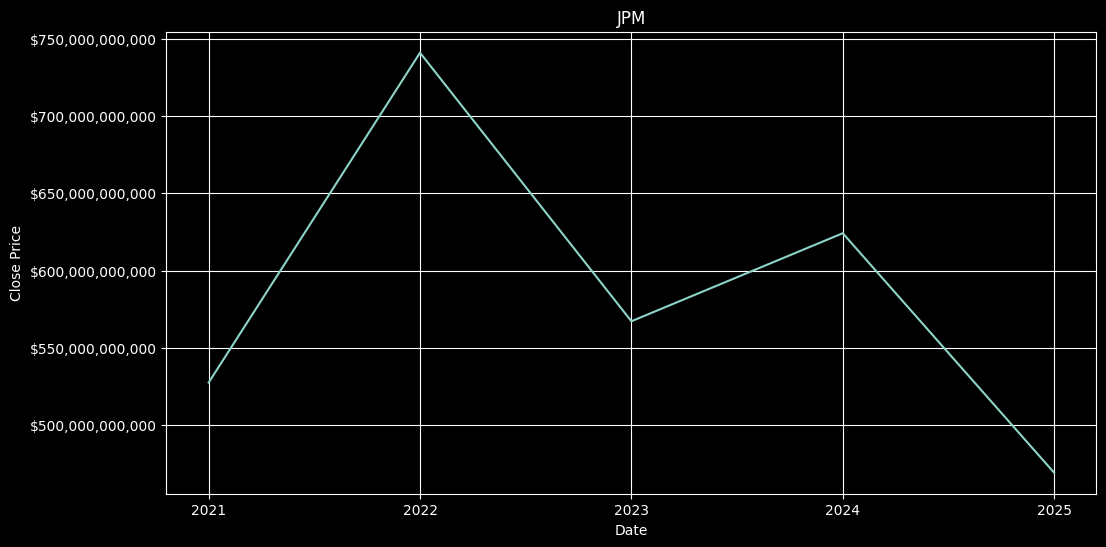

Cash Beginning of Period DataFrame:
   Date  Cash Beginning of Period
0  2021            527609000000.0
1  2022            740834000000.0
2  2023            567234000000.0
3  2024            624151000000.0
4  2025            469317000000.0


In [ ]:
x13, y13 = pull_and_plot(cash_flow_statement_annually, 'Cash Beginning of Period')
print("Cash Beginning of Period DataFrame:")
print(pd.DataFrame({'Date': x13.astype(str), 'Cash Beginning of Period': y13}).sort_values(by='Date'))

## Operating Cash Flow

Operating cash flow refers to the amount of cash generated or used by a company from its normal business operations, such as taking deposits, making loans, and collecting fees, in JPM's case. It is an important metric for investors and analysts to evaluate a company's financial performance, since it indicates the company's ability to generate cash from its operations and pay its bills, independent of financing or investing decisions. A positive operating cash flow indicates that the company is generating enough cash to cover its operating expenses, while a negative operating cash flow may indicate financial difficulties and the need for additional funding. Note that this line item is functionally the same figure introduced earlier as "Net Cash Provided by Operating Activities"; financetoolkit exposes it under a second row label as well, which is why it reappears here.

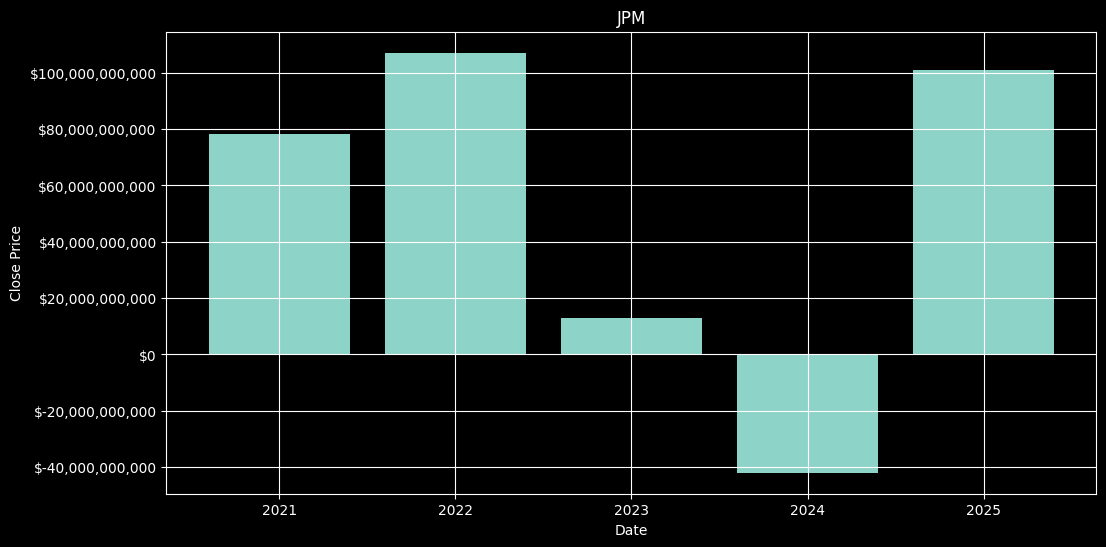

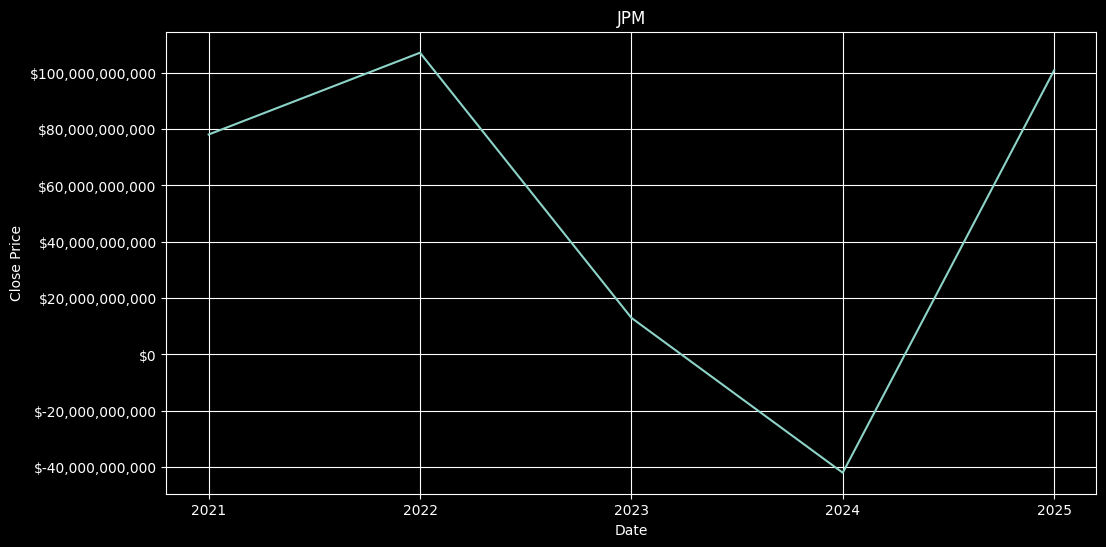

Operating Cash Flow DataFrame:
   Date  Operating Cash Flow
0  2021        78084000000.0
1  2022       107119000000.0
2  2023        12974000000.0
3  2024       -42012000000.0
4  2025       100867000000.0


In [ ]:
x14,y14 = pull_and_plot(cash_flow_statement_annually, 'Operating Cash Flow')
print("Operating Cash Flow DataFrame:")
print(pd.DataFrame({'Date': x14.astype(str), 'Operating Cash Flow': y14}).sort_values(by='Date'))

## Capital Expenditure

Capital expenditures (CapEx) represent cash spent on long-term assets such as property, plant, and equipment. On a cash flow statement, CapEx is reported as a cash outflow from investing activities, so it is conventionally shown as a negative number: the larger the magnitude, the more cash the company spent buying or upgrading long-term assets during that period. A CapEx figure close to zero or positive would be unusual for an established company and would typically mean proceeds from selling assets exceeded new purchases that year.

CapEx is worth tracking alongside operating cash flow because it shows how much of the cash a company generates gets reinvested back into the business rather than being available for dividends, buybacks, or debt paydown. That relationship is exactly what free cash flow, covered next, is meant to capture.

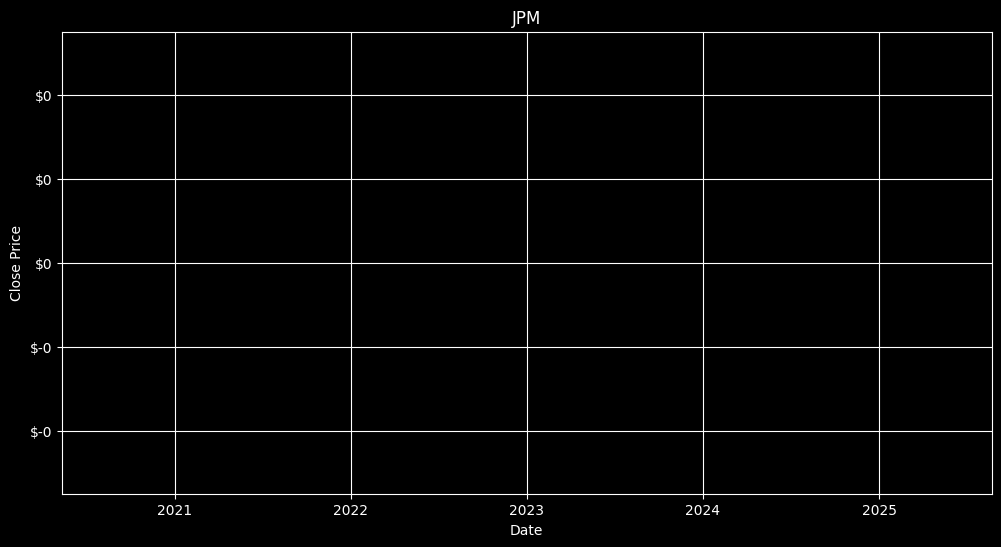

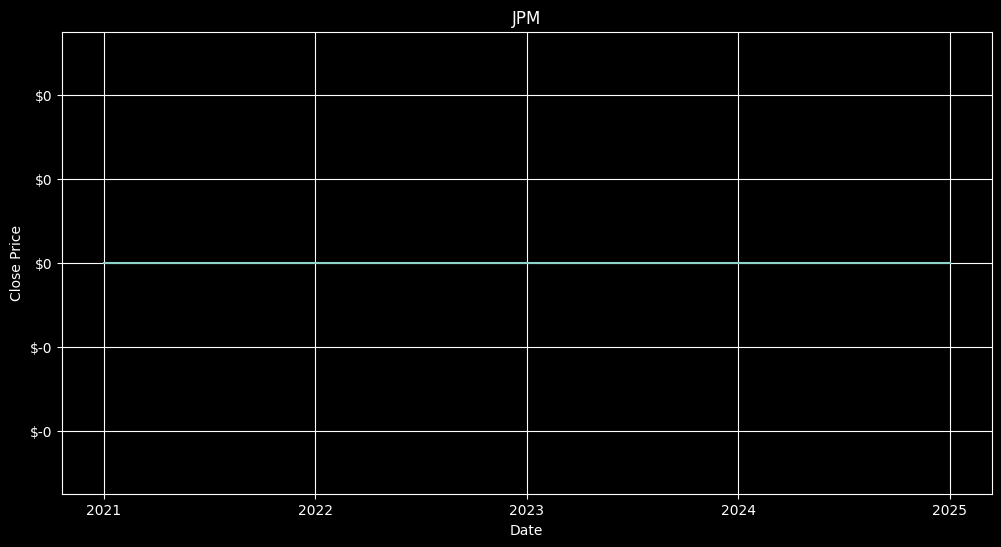

Capital Expenditure DataFrame:
   Date  Capital Expenditure
0  2021                  0.0
1  2022                  0.0
2  2023                  0.0
3  2024                  0.0
4  2025                  0.0


In [ ]:
x15,y15 = pull_and_plot(cash_flow_statement_annually, 'Capital Expenditure')
print("Capital Expenditure DataFrame:")
print(pd.DataFrame({'Date': x15.astype(str), 'Capital Expenditure': y15}).sort_values(by='Date'))

## Free Cash Flow

Free cash flow is a measure of a company's financial performance that represents the amount of cash available for distribution after accounting for capital expenditures. It is calculated as operating cash flow minus capital expenditures. It is a useful metric for investors to assess a company's ability to generate cash after accounting for the reinvestment needed to maintain and grow its operations. A positive free cash flow indicates that a company has cash available for paying dividends, repurchasing shares, paying off debt, or acquiring other businesses, without needing to raise additional outside financing to do so.

Free cash flow is often treated as a more reliable valuation input than net income because, like operating cash flow, it is harder to manipulate with accounting choices and reflects cash that management actually has discretion over. Comparing free cash flow across the years pulled here against the dividends paid and common stock purchased figures from earlier sections shows whether JPM's shareholder returns have been comfortably covered by the cash it generates.

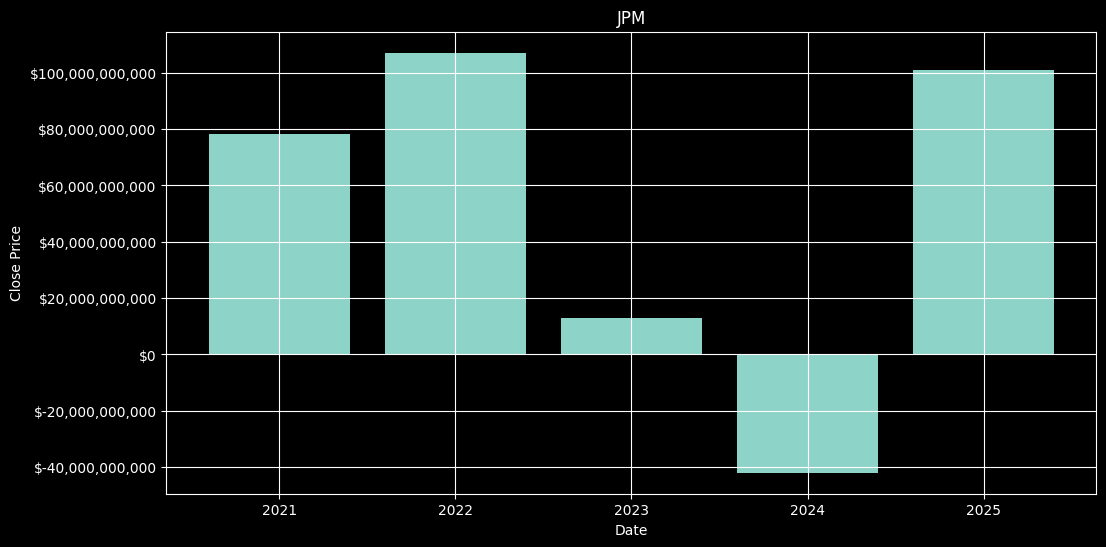

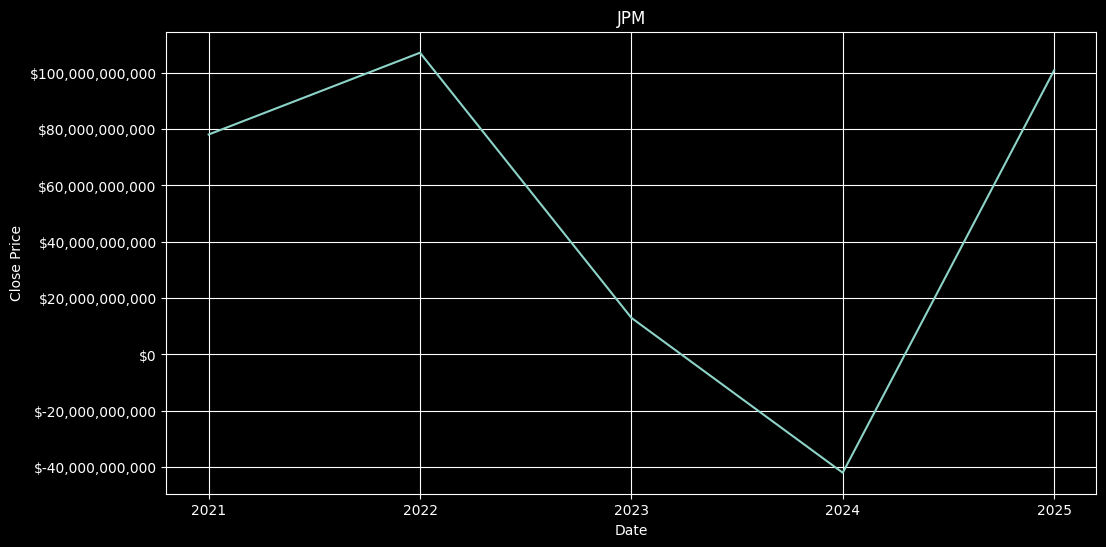

Free Cash Flow DataFrame:
   Date  Free Cash Flow
0  2021   78084000000.0
1  2022  107119000000.0
2  2023   12974000000.0
3  2024  -42012000000.0
4  2025  100867000000.0


In [ ]:
x16,y16 = pull_and_plot(cash_flow_statement_annually, 'Free Cash Flow')
print("Free Cash Flow DataFrame:")
print(pd.DataFrame({'Date': x16.astype(str), 'Free Cash Flow': y16}).sort_values(by='Date'))